In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df  = pd.read_csv("Medkart_Analytics_Final.csv")

In [4]:
df.head(5)


,patientID,physID,NDC,qty,days,refills,status,firstName,lastName,birthdate,...,expDate,supID,purchasePrice,sellPrice,name_supplier,address_supplier,phone_supplier,revenue,cost,profit
0,2,2,78965,30,30,5,picked up,Huda,Saleh,09/22/1999,...,05/23,1,5.45,6.78,Cardinal Health,"7000 Cardinal Place, Dublin, OH 43017",(614)553-4460,203.4,163.5,39.9
1,2,2,23567,30,30,0,picked up,Huda,Saleh,09/22/1999,...,09/22,1,11.23,12.55,Cardinal Health,"7000 Cardinal Place, Dublin, OH 43017",(614)553-4460,376.5,336.9,39.6
2,2,2,43234,60,30,5,picked up,Huda,Saleh,09/22/1999,...,12/22,2,33.43,40.33,McKesson,"6555 Sate Hwy, Irving, TX 75039",(734)427-2000,2419.8,2005.8,414.0
3,7,1,23467,30,30,2,filled,Milly,Roger,11/12/1950,...,05/23,1,12.44,14.54,Cardinal Health,"7000 Cardinal Place, Dublin, OH 43017",(614)553-4460,436.2,373.2,63.0
4,5,7,12365,15,15,0,NaN,Mona,Berry,04/23/2009,...,12/24,1,14.56,17.88,Cardinal Health,"7000 Cardinal Place, Dublin, OH 43017",(614)553-4460,268.2,218.4,49.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patientID         15 non-null     int64  
 1   physID            15 non-null     int64  
 2   NDC               15 non-null     int64  
 3   qty               15 non-null     int64  
 4   days              15 non-null     int64  
 5   refills           15 non-null     int64  
 6   status            11 non-null     object 
 7   firstName         15 non-null     object 
 8   lastName          15 non-null     object 
 9   birthdate         15 non-null     object 
 10  address           15 non-null     object 
 11  phone             15 non-null     object 
 12  gender            13 non-null     object 
 13  insurance         15 non-null     object 
 14  name              15 non-null     object 
 15  address_doctor    15 non-null     object 
 16  phone_doctor      15 non-null     object 
 17 

In [6]:
df.shape

(15, 30)

In [7]:
df.describe()

,patientID,physID,NDC,qty,days,refills,dosage,supID,purchasePrice,sellPrice,revenue,cost,profit
count,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,5.666667,3.733333,41429.133333,36.00000,30.000000,2.533333,48.666667,1.266667,13.272000,15.647333,597.850000,503.680000,94.170000
std,4.099942,3.011091,22423.737050,15.83396,13.887301,2.325838,28.564880,0.457738,10.379694,11.578245,604.637275,515.358507,103.532886
min,1.000000,1.000000,12365.000000,15.00000,15.000000,0.000000,10.000000,1.000000,2.340000,4.330000,64.950000,48.300000,16.650000
25%,2.000000,1.000000,23517.000000,30.00000,22.500000,0.000000,22.500000,1.000000,6.110000,7.335000,236.700000,183.300000,39.600000
50%,5.000000,2.000000,34543.000000,30.00000,30.000000,3.000000,50.000000,1.000000,11.230000,12.550000,376.500000,336.900000,59.700000
75%,7.000000,6.000000,56787.000000,45.00000,30.000000,5.000000,70.000000,1.500000,14.050000,16.935000,898.500000,751.800000,93.600000
max,14.000000,9.000000,78987.000000,60.00000,60.000000,5.000000,100.000000,2.000000,35.670000,40.330000,2419.800000,2005.800000,414.000000


In [8]:
print(df.isnull().sum())

patientID           0
physID              0
NDC                 0
qty                 0
days                0
refills             0
status              4
firstName           0
lastName            0
birthdate           0
address             0
phone               0
gender              2
insurance           0
name                0
address_doctor      0
phone_doctor        0
brandName           0
genericName         0
dosage              0
expDate             0
supID               0
purchasePrice       0
sellPrice           0
name_supplier       0
address_supplier    0
phone_supplier      0
revenue             0
cost                0
profit              0
dtype: int64


In [9]:
df['gender'] = df['gender'].fillna('Unknown')

In [10]:
df['status'] = df['status'].fillna('Unknown')

In [11]:
print(df.isnull().sum())

patientID           0
physID              0
NDC                 0
qty                 0
days                0
refills             0
status              0
firstName           0
lastName            0
birthdate           0
address             0
phone               0
gender              0
insurance           0
name                0
address_doctor      0
phone_doctor        0
brandName           0
genericName         0
dosage              0
expDate             0
supID               0
purchasePrice       0
sellPrice           0
name_supplier       0
address_supplier    0
phone_supplier      0
revenue             0
cost                0
profit              0
dtype: int64


In [12]:
total_revenue = df['revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8967.75


In [13]:
drug_revenue = (
    df.groupby('brandName')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(drug_revenue)

brandName
Neurontin    3549.60
Aldactone    1148.40
Amoxil        959.40
Ambien        916.80
Lipitor       753.00
Cozaar        676.80
Zocor         436.20
Motrin        259.80
Mobic         202.80
Lasix          64.95
Name: revenue, dtype: float64


In [14]:
import matplotlib.pyplot as plt

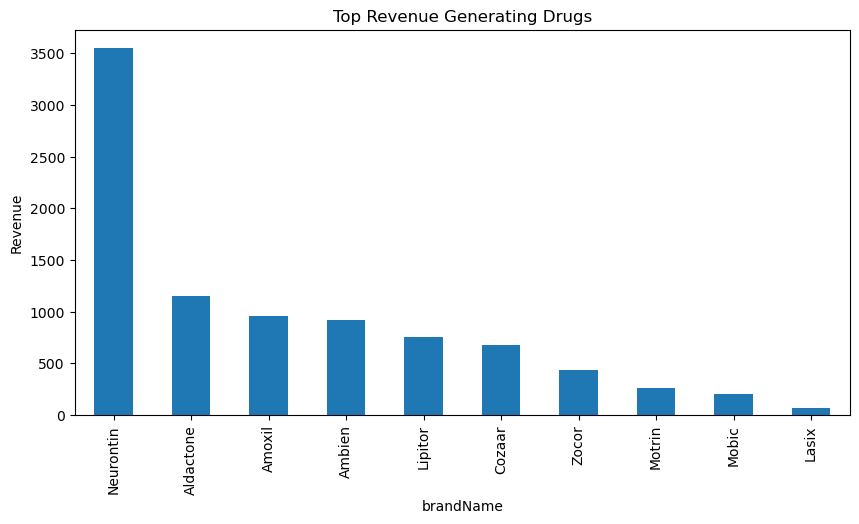

In [15]:
drug_revenue.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Revenue Generating Drugs")
plt.ylabel("Revenue")
plt.show()

In [16]:
total_profit = df['profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 1412.5499999999993


In [17]:
drug_profit = (
    df.groupby('brandName')['profit']
    .sum()
    .sort_values(ascending=False)
)

print(drug_profit)

brandName
Neurontin    473.70
Amoxil       219.00
Ambien       153.60
Motrin       119.40
Aldactone    117.60
Cozaar       107.10
Lipitor       79.20
Mobic         63.30
Zocor         63.00
Lasix         16.65
Name: profit, dtype: float64


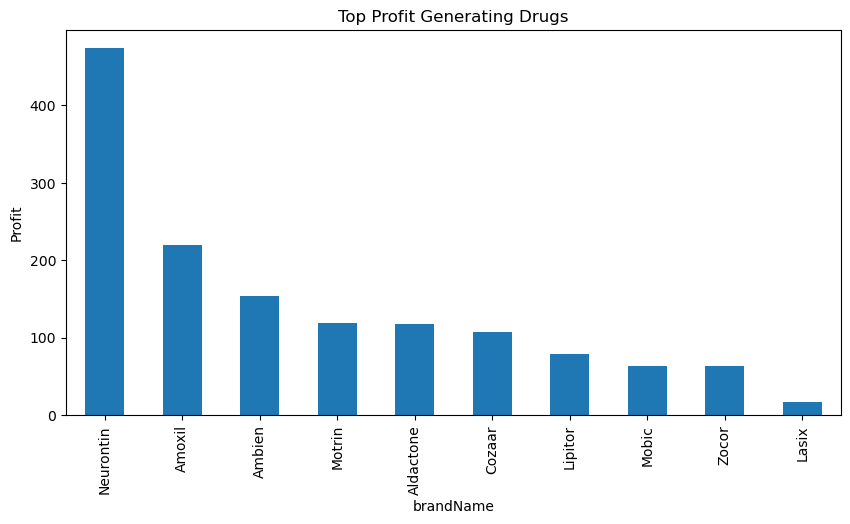

In [18]:
drug_profit.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Profit Generating Drugs")
plt.ylabel("Profit")
plt.show()

In [19]:
df['profit_margin'] = (df['profit'] / df['revenue']) * 100

In [20]:
print(
    "Average Margin:",
    round(df['profit_margin'].mean(),2),
    "%"
)

Average Margin: 18.3 %


In [21]:
supplier_rev = (
    df.groupby('name_supplier')['revenue']
      .sum()
      .sort_values(ascending=False)
)

In [22]:
print(supplier_rev)

name_supplier
McKesson           4726.20
Cardinal Health    4241.55
Name: revenue, dtype: float64


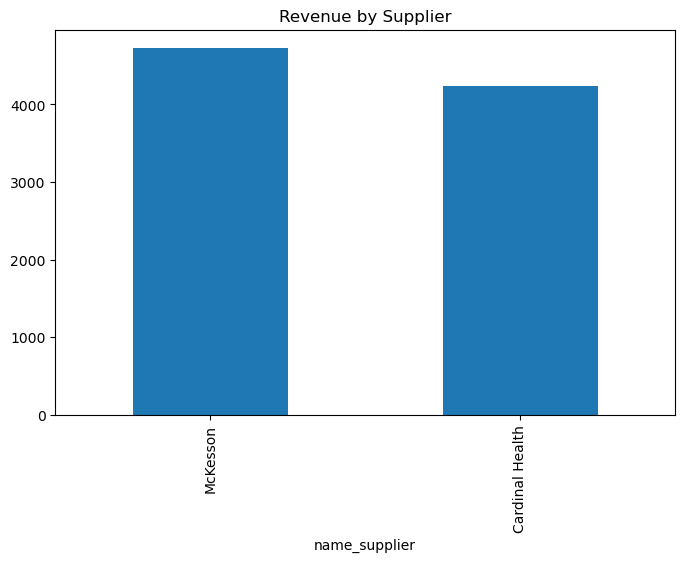

In [24]:
supplier_rev.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Supplier")
plt.show()

In [ ]:
top_drugs = (
    df.groupby('brandName')['qty']
    .sum()
    .sort_values(ascending=False)
)

print(top_drugs)

In [ ]:
df['patient_name'] = (
    df['firstName'] + " " +
    df['lastName']
)

In [ ]:
patient_revenue = (
    df.groupby('patient_name')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(patient_revenue)

In [ ]:
gender_count = (
    df['gender']
    .value_counts()
)

print(gender_count)

In [ ]:
gender_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.show()

In [ ]:
print(
    df['refills']
    .value_counts()
)

In [ ]:
df['refills'].hist(
    bins=10
)

plt.title("Refill Distribution")
plt.show()

In [ ]:
insurance_analysis = (
    df.groupby('insurance')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(insurance_analysis)

In [ ]:
doctor_revenue = (
    df.groupby('name')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(doctor_revenue)

In [ ]:
print("="*50)

print("PHARMACY ANALYTICS SUMMARY")

print("="*50)

print("Total Revenue:",
      df['revenue'].sum())

print("Total Profit:",
      df['profit'].sum())

print("Total Patients:",
      df['patientID'].nunique())

print("Total Doctors:",
      df['physID'].nunique())

print("Total Prescriptions:",
      len(df))

print("="*50)